# total mensual de viajeros internacionales



In [200]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from statsmodels.tsa.seasonal import seasonal_decompose

pd.set_option("display.max_columns" , None)

In [201]:
archivo = Path( "Laboratorio 1. Series de Tiempo 2026 - Base_Migracion_2009-2026jun.xlsx" )

if not archivo.exists(): raise FileNotFoundError(f"no está el archivo: {archivo.resolve()}" )
datos = pd.read_excel(archivo)

print("dataset:", datos.shape)
print(datos.columns.tolist())

datos.head()

dataset: (161036, 13)
['Año', 'Mes cod', 'Mes', 'Vía', 'Frontera', 'País', 'Región', 'Región dos', 'Regiones OMT', 'MCEO', 'Agrupación Residencia', 'Tipo de Viajero', 'Viajero']


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0


In [202]:
columnas_necesarias={
    "Año",
    "Mes cod",
    "Tipo de Viajero",
    "Viajero"
}

los_faltantes = columnas_necesarias - set( datos.columns)

if los_faltantes: raise KeyError( "Faltan estas columnas: " + ", ".join(sorted(los_faltantes)))

print("todas las columnas necesarias están.")

todas las columnas necesarias están.


In [203]:
datos["Año"] = pd.to_numeric( datos[ "Año"], errors ="coerce")
datos["Mes cod"] = pd.to_numeric(datos["Mes cod"], errors ="coerce")
datos["Viajero"] = pd.to_numeric( datos["Viajero"] , errors ="coerce")

datos["Fecha"] = pd.to_datetime(
    {"year": datos["Año"], "month": datos["Mes cod"], "day": 1},

    errors ="coerce"
)

print("fechas inválidas:", datos["Fecha"].isna().sum())
print("valores inválidos en Viajero:", datos["Viajero"].isna().sum())

print("fecha mínima:", datos["Fecha"].min())
print("fecha máxima:", datos["Fecha"].max())

fechas inválidas: 0
valores inválidos en Viajero: 0
fecha mínima: 2009-01-01 00:00:00
fecha máxima: 2026-06-01 00:00:00


In [204]:
datos["Tipo de Viajero"].value_counts(dropna=False)

Tipo de Viajero
Turista          117912
Viajero           23190
Excursionista     19730
Cruceristas         204
Name: count, dtype: int64

### Copia con filtro
en las notas del dataset dice que la categoría Viajero tuvo un cambio fuerte entre 2022 y 2023 por lo que no conviene incluirla en la serie comparable del período completo.

para construir esta serie solo están las categorías Turista y Excursionista, debido a que son comparables durante todo el período

In [205]:
tipos_seleccionados = ["Turista", "Excursionista"]

datos_visitantes = datos[datos["Tipo de Viajero"].isin(tipos_seleccionados)].copy()

datos["Tipo de Viajero"].isin(tipos_seleccionados)


0          True
1          True
2          True
3          True
4          True
          ...  
161031     True
161032    False
161033     True
161034    False
161035     True
Name: Tipo de Viajero, Length: 161036, dtype: bool

In [206]:
print("Filas originales:", len(datos))
print("Filas después del filtro:", len(datos_visitantes))

print("\nTipos de viajero incluidos:")
print(datos_visitantes["Tipo de Viajero"].value_counts())

Filas originales: 161036
Filas después del filtro: 137642

Tipos de viajero incluidos:
Tipo de Viajero
Turista          117912
Excursionista     19730
Name: count, dtype: int64


### construcción

In [207]:
serie_total = (
    datos_visitantes
    .dropna(subset=["Fecha", "Viajero"])
    .groupby("Fecha")["Viajero"]
    .sum()
    .sort_index()
    .asfreq("MS")
)

serie_total.name = "total_mensual"

print("inicio:", serie_total.index.min() )
print("fin:", serie_total.index.max() )
print("frecuencia:", serie_total.index.freqstr )
print("número de observaciones:" , len(serie_total ) )
print("meses faltantes:" , serie_total.isna().sum() )

serie_total.head()

inicio: 2009-01-01 00:00:00
fin: 2026-06-01 00:00:00
frecuencia: MS
número de observaciones: 210
meses faltantes: 0


Fecha
2009-01-01    149944.029345
2009-02-01    127303.692203
2009-03-01    158795.673819
2009-04-01    172013.467694
2009-05-01    124559.524351
Freq: MS, Name: total_mensual, dtype: float64

### Estadísticas

In [208]:
estadisticas = serie_total.describe()
estadisticas

count       210.000000
mean     222437.680412
std       84724.938827
min        9779.000000
25%      170714.476564
50%      227605.662595
75%      278341.208767
max      449114.070500
Name: total_mensual, dtype: float64

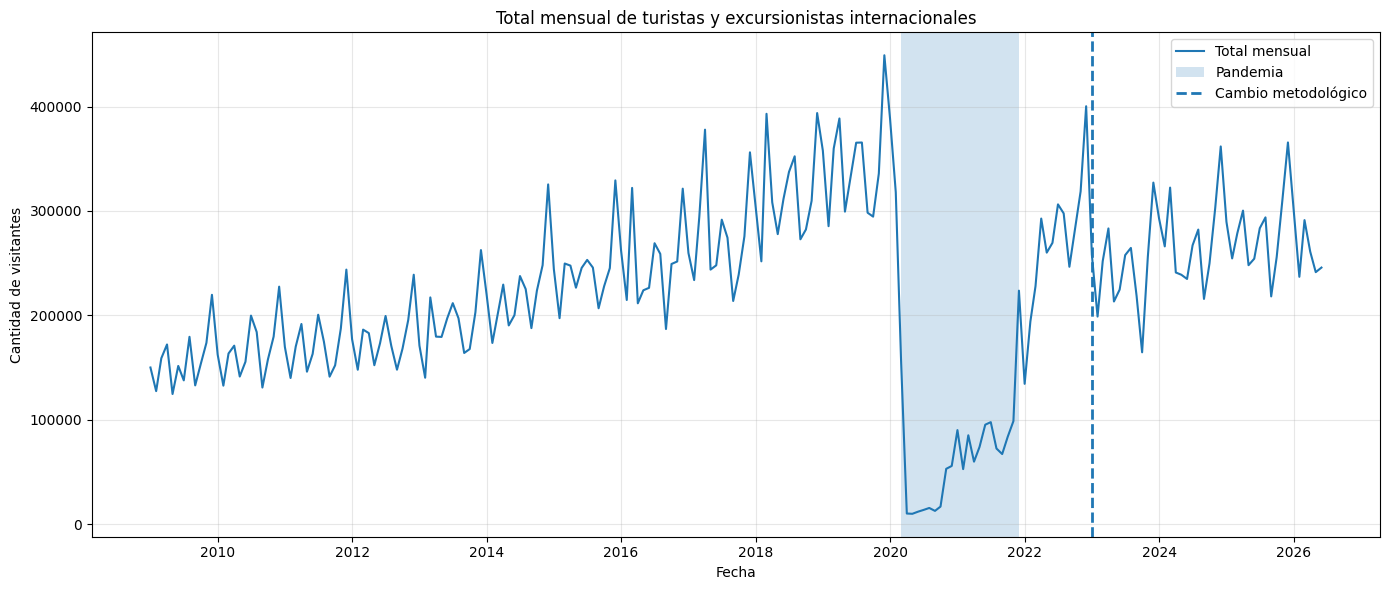

In [209]:
plt.figure(figsize= (14, 6) )

plt.plot(serie_total.index,serie_total,label="Total mensual")

plt.axvspan(
    pd.Timestamp("2020-03-01"),
    pd.Timestamp("2021-12-01"),
    alpha=0.2 , label= "Pandemia"
)

plt.axvline(
    pd.Timestamp("2023-01-01"),
    linestyle="--", linewidth = 2 ,
    label="Cambio metodológico"
)

plt.title("Total mensual de turistas y excursionistas internacionales")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de visitantes")
plt.legend()
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

### media móvil de 12 meses

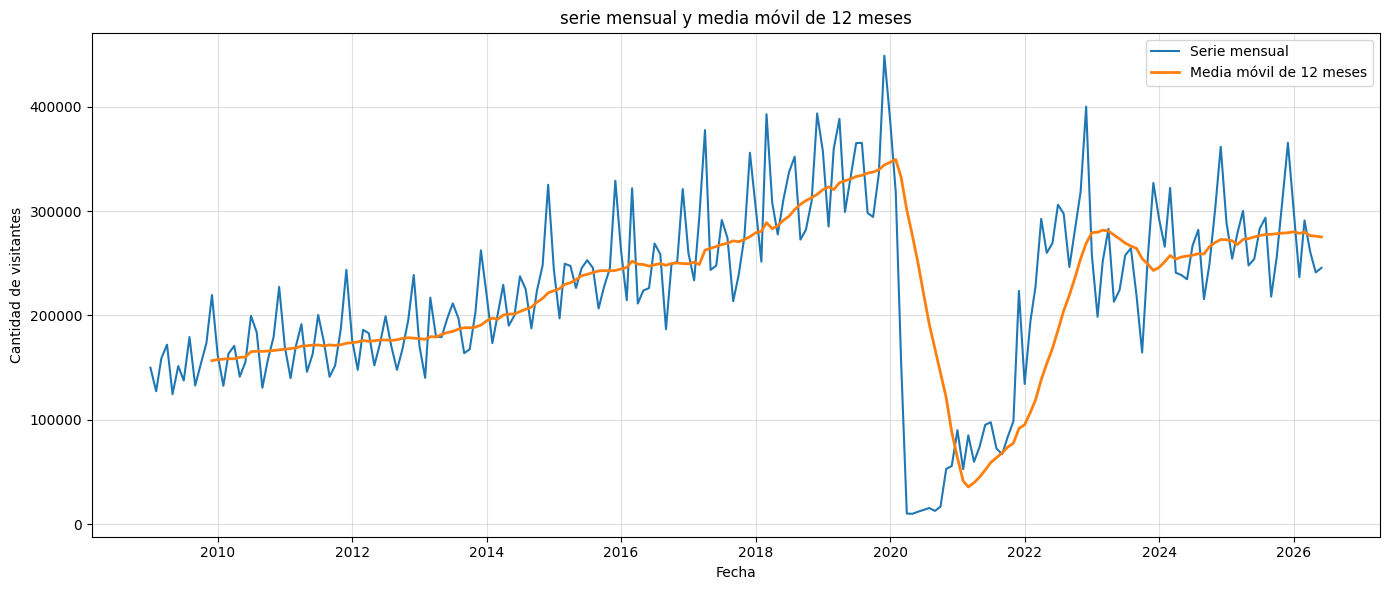

In [210]:
media_movil_12 = serie_total.rolling(12).mean()

plt.figure(figsize =( 14, 6))

plt.plot( serie_total.index,
    serie_total,
    label="Serie mensual"
)

plt.plot( media_movil_12.index,
    media_movil_12 ,
    linewidth = 2,
    label="Media móvil de 12 meses"
)

plt.title("serie mensual y media móvil de 12 meses" )
plt.xlabel("Fecha")
plt.ylabel( "Cantidad de visitantes")
plt.legend()
plt.grid(alpha = 0.4)
plt.tight_layout()
plt.show()

In [211]:
cantidad_entrenamiento =  int( len(serie_total) * 0.70 )
serie_entrenamiento =  serie_total.iloc[:cantidad_entrenamiento ]
serie_prueba = serie_total.iloc[ cantidad_entrenamiento: ]

print("totales:" , len(serie_total) )
print("Observaciones de entrenamiento:" , len(serie_entrenamiento))
print("Observaciones de prueba:" , len(serie_prueba) )
print("\n fecha inicio:", serie_entrenamiento.index.min())
print("fecha fin:" , serie_entrenamiento.index.max())
print("\nfecha inicio prueba:" , serie_prueba.index.min())
print("fecha fin prueba:" , serie_prueba.index.max() )

totales: 210
Observaciones de entrenamiento: 147
Observaciones de prueba: 63

 fecha inicio: 2009-01-01 00:00:00
fecha fin: 2021-03-01 00:00:00

fecha inicio prueba: 2021-04-01 00:00:00
fecha fin prueba: 2026-06-01 00:00:00


### descomposicion aditivA

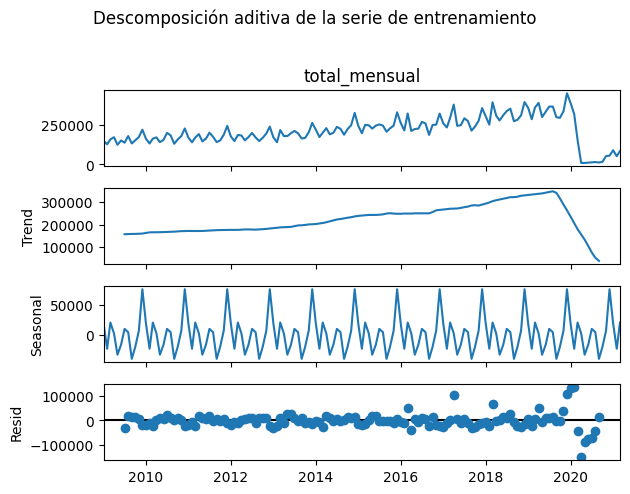

In [212]:
descomposicion = seasonal_decompose( serie_entrenamiento, model="additive", period=12 )
descomposicion.plot()

plt.suptitle("Descomposición aditiva de la serie de entrenamiento", y= 1.02 )

plt.tight_layout()
plt.show()

### descomposición multiplicativa

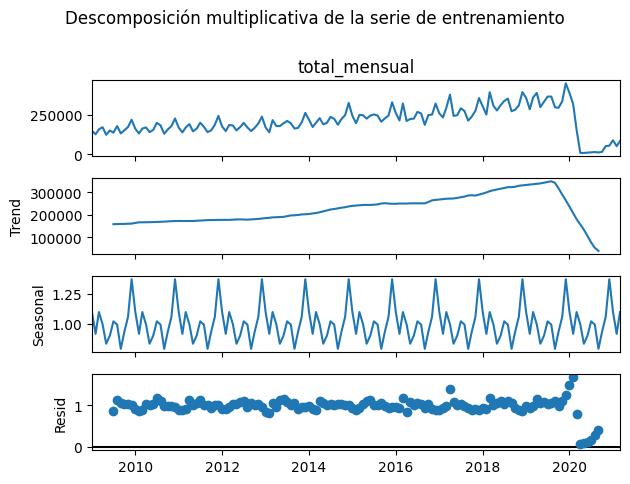

In [213]:
descomposicion_multiplicativa = seasonal_decompose( serie_entrenamiento, model= "multiplicative", period =12 )

descomposicion_multiplicativa.plot()

plt.suptitle( "Descomposición multiplicativa de la serie de entrenamiento", y=1)

plt.tight_layout()
plt.show()

### transformación logarítmica

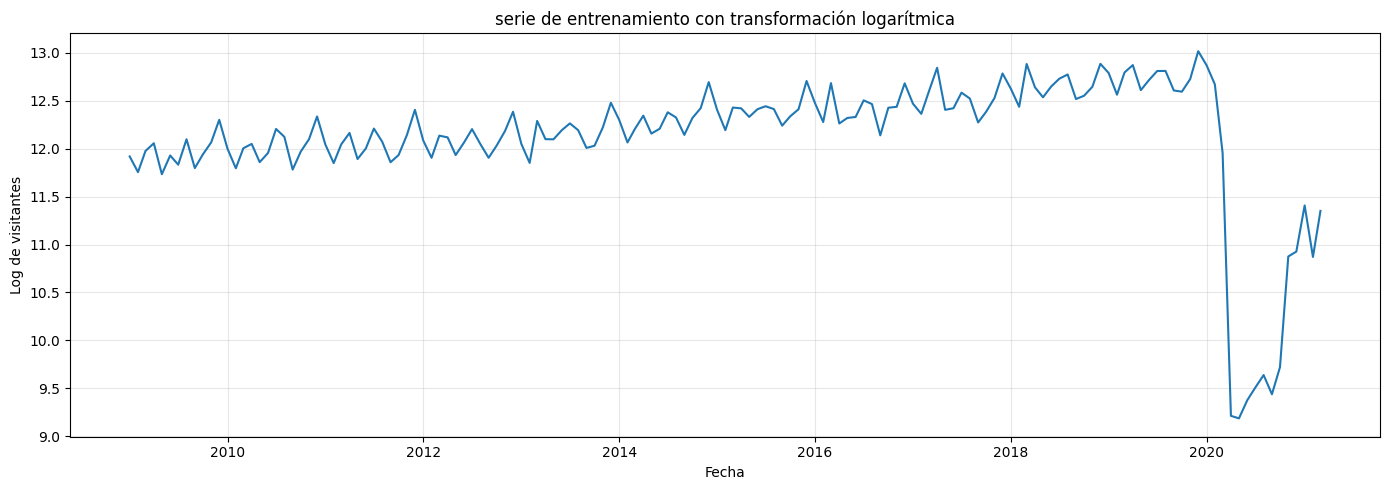

In [214]:
serie_log = np.log( serie_entrenamiento)

plt.figure(figsize= ( 14, 5) )

plt.plot( serie_log.index, serie_log)

plt.title("serie de entrenamiento con transformación logarítmica")
plt.xlabel("Fecha")
plt.ylabel("Log de visitantes")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### autocorrelación

<Figure size 1200x500 with 0 Axes>

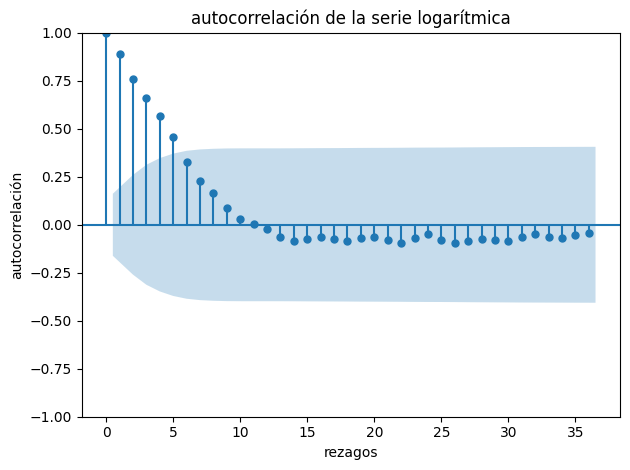

In [215]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize= ( 12, 5) )

plot_acf( serie_log, lags=36 )

plt.title("autocorrelación de la serie logarítmica")
plt.xlabel("rezagos")
plt.ylabel("autocorrelación")
plt.tight_layout()
plt.show()

### prueba Dickey-Fuller aumentada

In [216]:
from statsmodels.tsa.stattools import adfuller

resultado_adf =adfuller(serie_log )

print("estadístico ADF:", resultado_adf[ 0 ] )
print("valor p:", resultado_adf[1 ] )
print("Número de rezagos utilizados:", resultado_adf[2] )
print("Número de observaciones:", resultado_adf[3 ] )

print("\nvalores críticos:")
for nivel, valor in resultado_adf[4].items():print(f"{nivel}: {valor}")

estadístico ADF: -2.4992890826669516
valor p: 0.1156473944573862
Número de rezagos utilizados: 12
Número de observaciones: 134

valores críticos:
1%: -3.480118600110386
5%: -2.8833618426136196
10%: -2.578407034974382


### primera diferenciazión

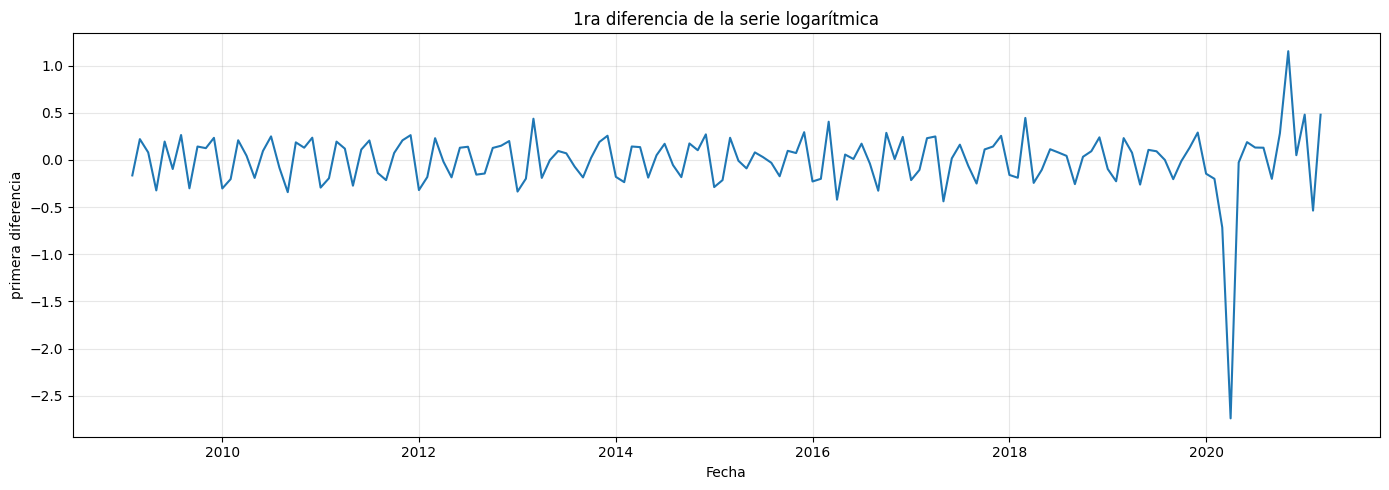

In [217]:
serie_diferenciada = serie_log.diff().dropna()

plt.figure( figsize= (14 , 5) )
plt.plot(serie_diferenciada.index, serie_diferenciada)

plt.title("1ra diferencia de la serie logarítmica")
plt.xlabel("Fecha")
plt.ylabel("primera diferencia")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

repertir la prueba

In [218]:
resultado_adf_diferenciada = adfuller( serie_diferenciada)
print("ADF:", resultado_adf_diferenciada[0 ] )
print("valor p:", resultado_adf_diferenciada[1 ] )  
print("Número de rezagos utilizados:" , resultado_adf_diferenciada[2])
print("Número de observaciones:" , resultado_adf_diferenciada[3])

print("\nValores críticos:")
for nivel, valor in resultado_adf_diferenciada[4].items():
    print(f"{nivel}: {valor}")

ADF: -3.0852899670037477
valor p: 0.027661123195754683
Número de rezagos utilizados: 11
Número de observaciones: 134

Valores críticos:
1%: -3.480118600110386
5%: -2.8833618426136196
10%: -2.578407034974382


### correlación

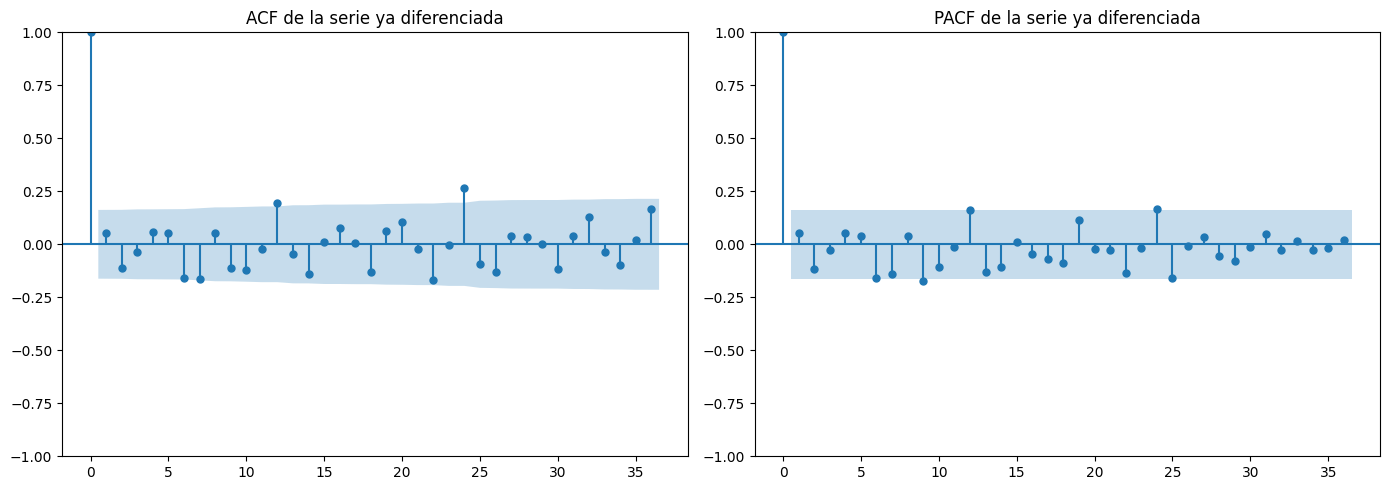

In [219]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ejes = plt.subplots(1 ,  2, figsize= ( 14, 5) )

plot_acf(serie_diferenciada, lags=36, ax=ejes[0] )

plot_pacf(
    serie_diferenciada,
    lags=36,
    ax=ejes[1],
    method="ywm"
)

ejes[0].set_title("ACF de la serie ya diferenciada")
ejes[1].set_title("PACF de la serie ya diferenciada")

plt.tight_layout()
plt.show()

### diferencia estacional

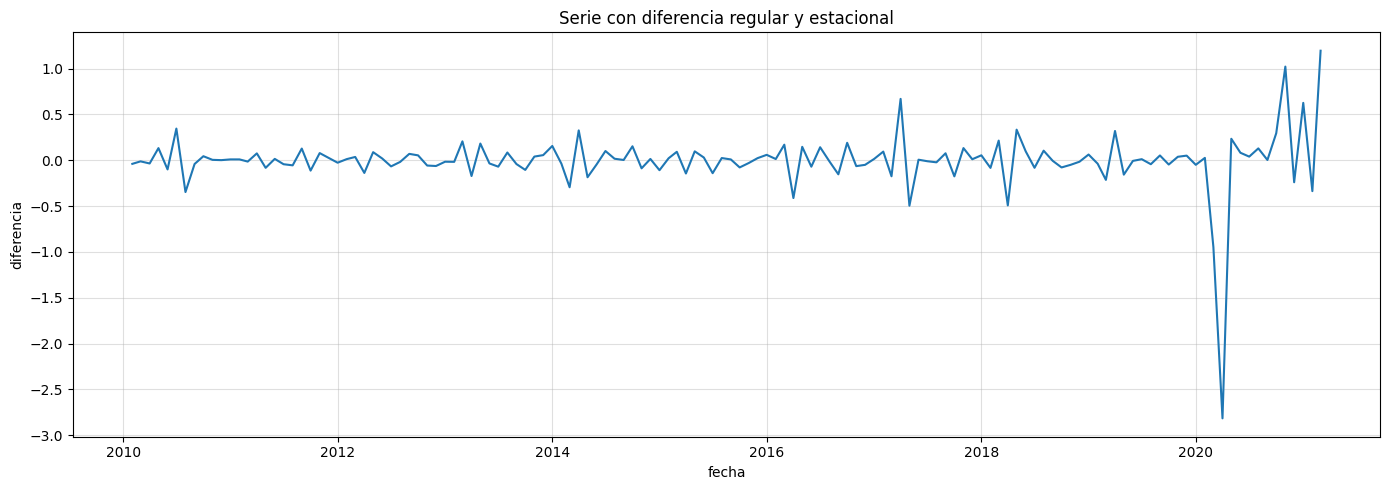

In [220]:
serie_diferenciada_estacional = ( serie_diferenciada.diff(12).dropna())

plt.figure(figsize=(14, 5))

plt.plot(serie_diferenciada_estacional.index, serie_diferenciada_estacional)

plt.title("Serie con diferencia regular y estacional")
plt.xlabel("fecha")
plt.ylabel("diferencia")
plt.grid(alpha= 0.4 )
plt.tight_layout()
plt.show()

In [221]:
resultado_adf_estacional = adfuller( serie_diferenciada_estacional )

print("ADF:", resultado_adf_estacional[0])
print("Valor p:", resultado_adf_estacional[1])
print("Número de rezagos utilizados:", resultado_adf_estacional[2])
print( "Número de observaciones:", resultado_adf_estacional[3])

print("\nValores críticos:")
for nivel, valor in resultado_adf_estacional[4].items(): print(f"{nivel}: {valor}")

ADF: -6.5385970466618994
Valor p: 9.470702986370814e-09
Número de rezagos utilizados: 11
Número de observaciones: 122

Valores críticos:
1%: -3.4851223522012855
5%: -2.88553750045158
10%: -2.5795685622144586


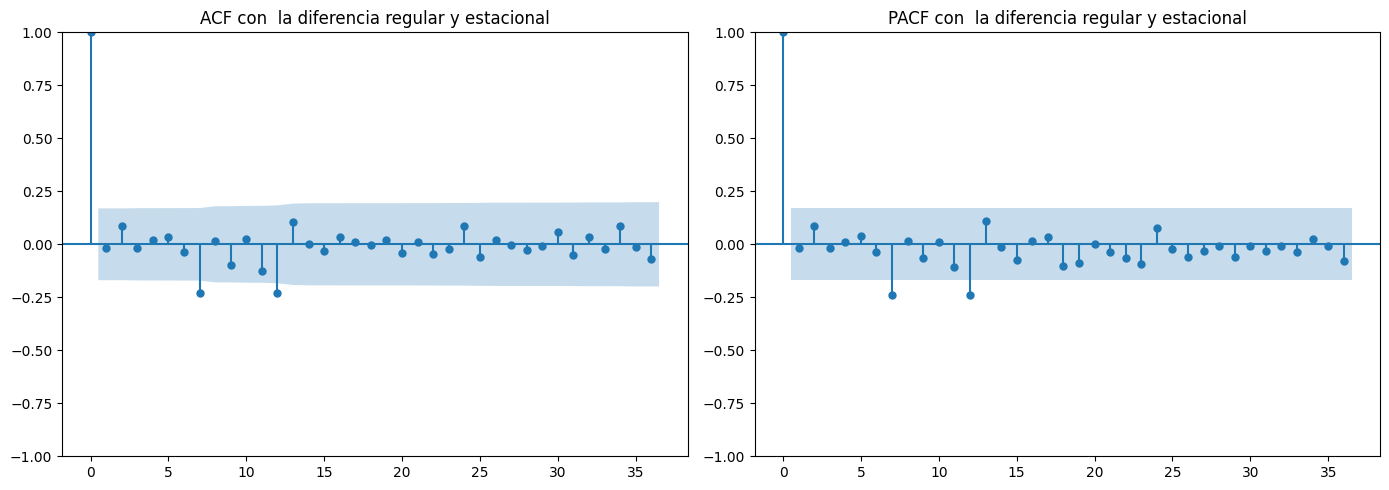

In [222]:
fig, ejes = plt.subplots(1, 2, figsize = (14,5 ) )

plot_acf(serie_diferenciada_estacional, lags=36, ax= ejes[0 ] )

plot_pacf(
    serie_diferenciada_estacional,
    lags=36,
    ax=ejes[1],
    method="ywm"
)

ejes[0].set_title("ACF con  la diferencia regular y estacional")
ejes[1].set_title("PACF con  la diferencia regular y estacional")

plt.tight_layout()
plt.show()

### SARIMAX

In [223]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

modelo_sarima_1 = SARIMAX(
    serie_log, order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

ajuste_sarima_1 = modelo_sarima_1.fit()

print(ajuste_sarima_1.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      total_mensual   No. Observations:                  147
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 -31.376
Date:                            Fri, 24 Jul 2026   AIC                             68.752
Time:                                    18:00:33   BIC                             77.114
Sample:                                01-01-2009   HQIC                            72.148
                                     - 03-01-2021                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0835      0.075      1.108      0.268      -0.064       0.231
ma.S.L12      -0.6938      0.167   

In [224]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

modelos_propuestos = [
    ((1, 1, 0), (1, 0, 0, 12)),
    ((0, 1, 1), (1, 0, 0, 12)),
    ((1, 1, 0), (0, 0, 1, 12)),
    ((0, 1, 1), (0, 0, 1, 12)),
    ((1, 1, 1), (1, 0, 0, 12)),
    ((1, 1, 1), (0, 0, 1, 12))
]

resultados_modelos = []

for orden, orden_estacional in modelos_propuestos:

    modelo = SARIMAX(
        serie_log,
        order=orden,
        seasonal_order=orden_estacional,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    ajuste = modelo.fit(disp=False)

    prediccion_log = ajuste.get_forecast(
        steps=len(serie_prueba)
    ).predicted_mean

    prediccion = np.exp(prediccion_log)
    prediccion.index = serie_prueba.index

    mae = mean_absolute_error(
        serie_prueba,
        prediccion
    )

    rmse = np.sqrt(
        mean_squared_error(
            serie_prueba,
            prediccion
        )
    )

    resultados_modelos.append({
        "orden": orden,
        "orden_estacional": orden_estacional,
        "aic": ajuste.aic,
        "bic": ajuste.bic,
        "mae": mae,
        "rmse": rmse
    })


comparacion_modelos = pd.DataFrame(resultados_modelos)

comparacion_modelos = comparacion_modelos.sort_values(
    by="rmse"
).reset_index(drop=True)

comparacion_modelos

,orden,orden_estacional,aic,bic,mae,rmse
0,"(1, 1, 1)","(0, 0, 1, 12)",88.645619,100.176827,162379.627536,175899.275709
1,"(0, 1, 1)","(0, 0, 1, 12)",86.775569,95.423974,163200.579623,176597.693467
2,"(1, 1, 0)","(0, 0, 1, 12)",86.796759,95.467806,164177.980889,177482.320221
3,"(1, 1, 1)","(1, 0, 0, 12)",79.466281,91.027678,196817.508362,209112.019029
4,"(1, 1, 0)","(1, 0, 0, 12)",77.469117,86.140165,196826.563713,209124.630902
5,"(0, 1, 1)","(1, 0, 0, 12)",77.167400,85.860920,197448.590818,209747.459499


In [225]:
modelo_sarima_final = SARIMAX(
    serie_log,
    order=(1, 1, 1),
    seasonal_order=(0, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

ajuste_sarima_final = modelo_sarima_final.fit(disp=False)

print(ajuste_sarima_final.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      total_mensual   No. Observations:                  147
Model:             SARIMAX(1, 1, 1)x(0, 0, 1, 12)   Log Likelihood                 -40.323
Date:                            Fri, 24 Jul 2026   AIC                             88.646
Time:                                    18:00:33   BIC                            100.177
Sample:                                01-01-2009   HQIC                            93.331
                                     - 03-01-2021                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2523      1.588     -0.159      0.874      -3.365       2.861
ma.L1          0.3337      1.549   

In [226]:
modelo_sarima_2 = SARIMAX(
    serie_log,
    order=(0, 1, 1),
    seasonal_order=(0, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

ajuste_sarima_2 = modelo_sarima_2.fit(disp=False)

print(ajuste_sarima_2.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      total_mensual   No. Observations:                  147
Model:             SARIMAX(0, 1, 1)x(0, 0, 1, 12)   Log Likelihood                 -40.388
Date:                            Fri, 24 Jul 2026   AIC                             86.776
Time:                                    18:00:33   BIC                             95.424
Sample:                                01-01-2009   HQIC                            90.290
                                     - 03-01-2021                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0744      0.120      0.623      0.534      -0.160       0.309
ma.S.L12       0.2166      0.186   

In [227]:
modelo_sarima_3 = SARIMAX(
    serie_log,
    order=(1, 1, 0),
    seasonal_order=(0, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

ajuste_sarima_3 = modelo_sarima_3.fit(disp=False)

print(ajuste_sarima_3.summary())

                                      SARIMAX Results                                       
Dep. Variable:                        total_mensual   No. Observations:                  147
Model:             SARIMAX(1, 1, 0)x(0, 0, [1], 12)   Log Likelihood                 -40.398
Date:                              Fri, 24 Jul 2026   AIC                             86.797
Time:                                      18:00:34   BIC                             95.468
Sample:                                  01-01-2009   HQIC                            90.320
                                       - 03-01-2021                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0613      0.127      0.481      0.630      -0.188       0.311
ma.S.L12       0.22

### Ljung-Box:

In [228]:
from statsmodels.stats.diagnostic import acorr_ljungbox

modelo_sarima_2 = SARIMAX (
    serie_log,
    order=(0, 1, 1 ) ,
    seasonal_order= (0, 0, 1, 12),
    enforce_stationarity = False,
    enforce_invertibility = False
)

ajuste_sarima_2 = modelo_sarima_2.fit(disp=False)

In [229]:
residuos_sarima_2 = ajuste_sarima_2.resid.dropna()

inicio_residuos = ajuste_sarima_2.loglikelihood_burn
residuos_sarima_2 = residuos_sarima_2.iloc[inicio_residuos:]

ljung_box_sarima_2 = acorr_ljungbox(
    residuos_sarima_2 ,
    lags=[12, 24, 36],
    model_df = 2 ,
    return_df = True
)

ljung_box_sarima_2

,lb_stat,lb_pvalue
12,11.768762,0.300830
24,25.493802,0.274048
36,32.942323,0.519321


### predicción final 

In [230]:
prediccion_log_sarima = ajuste_sarima_2.get_forecast(
    steps=len(serie_prueba)
).predicted_mean

prediccion_sarima = np.exp(prediccion_log_sarima)
prediccion_sarima.index = serie_prueba.index

mae_sarima = mean_absolute_error( serie_prueba, prediccion_sarima )

rmse_sarima = np.sqrt(
    mean_squared_error( serie_prueba, prediccion_sarima )
)

print("MAE SARIMA:" , mae_sarima)
print("RMSE SARIMA:" , rmse_sarima)

MAE SARIMA: 163200.5796225865
RMSE SARIMA: 176597.69346657785


### Holt-Winters

In [231]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

modelo_holt_winters = ExponentialSmoothing(
    serie_entrenamiento ,
    trend= "add" ,
    seasonal= "mul" ,
    seasonal_periods= 12
)

ajuste_holt_winters = modelo_holt_winters.fit()

prediccion_holt_winters = ajuste_holt_winters.forecast( len(serie_prueba) )

prediccion_holt_winters.index = serie_prueba.index

mae_holt_winters = mean_absolute_error( serie_prueba, prediccion_holt_winters )

rmse_holt_winters = np.sqrt(
    mean_squared_error( serie_prueba, prediccion_holt_winters )
)

print("MAE Holt-Winters:", mae_holt_winters)
print("RMSE Holt-Winters: " , rmse_holt_winters)

MAE Holt-Winters: 134374.79016800673
RMSE Holt-Winters:  146605.57630995588


In [232]:
modelos_holt_winters = [
    ("add", "add") ,
    ("add", "mul") ,
    ("mul", "add"),
    ("mul", "mul")
]

resultados_holt_winters = []

for tipo_tendencia, tipo_estacionalidad in modelos_holt_winters:

    modelo = ExponentialSmoothing(
        serie_entrenamiento,
        trend= tipo_tendencia,
        seasonal= tipo_estacionalidad,
        seasonal_periods = 12
    )

    ajuste = modelo.fit()

    prediccion = ajuste.forecast( len(serie_prueba) )

    prediccion.index = serie_prueba.index

    mae = mean_absolute_error(serie_prueba,prediccion)

    rmse = np.sqrt(
        mean_squared_error(
            serie_prueba,
            prediccion
        )
    )

    resultados_holt_winters.append({
        "tendencia": tipo_tendencia,
        "estacionalidad": tipo_estacionalidad,
        "mae": mae,
        "rmse": rmse
    })


comparacion_holt_winters = pd.DataFrame(resultados_holt_winters)

comparacion_holt_winters = (
    comparacion_holt_winters
    .sort_values("rmse")
    .reset_index(drop=True)
)

comparacion_holt_winters



    

,tendencia,estacionalidad,mae,rmse
0,add,mul,134374.790168,146605.576310
1,mul,mul,184484.061878,199959.747359
2,mul,add,189126.014950,202822.039899
3,add,add,255785.632250,276910.555450


### seasonal naïve

In [233]:
prediccion_seasonal_naive = serie_entrenamiento.iloc[-12:].to_numpy()

prediccion_seasonal_naive = np.tile( prediccion_seasonal_naive,  int(np.ceil(len(serie_prueba) / 12)) )

prediccion_seasonal_naive = prediccion_seasonal_naive[ :len(serie_prueba) ]

prediccion_seasonal_naive = pd.Series(
    prediccion_seasonal_naive,
    index=serie_prueba.index
)

mae_seasonal_naive = mean_absolute_error( serie_prueba, prediccion_seasonal_naive )

rmse_seasonal_naive = np.sqrt(
    mean_squared_error(
        serie_prueba,
        prediccion_seasonal_naive
    )
)

print("MAE Seasonal Naive:", mae_seasonal_naive)
print("RMSE Seasonal Naive:", rmse_seasonal_naive)

MAE Seasonal Naive: 207321.6373958207
RMSE Seasonal Naive: 219663.86935700072


### comparación

In [234]:
comparacion_final = pd.DataFrame({
    "modelo": [
        "SARIMA(0,1,1)(0,0,1,12)",
        "Holt-Winters add-mul" ,
        "Seasonal naive"
    ],
    "mae": [
        mae_sarima ,
        mae_holt_winters, mae_seasonal_naive
    ],
    "rmse": [
        rmse_sarima, rmse_holt_winters,
        rmse_seasonal_naive
    ]
})

comparacion_final = comparacion_final.sort_values( "rmse").reset_index(drop=True)

comparacion_final

,modelo,mae,rmse
0,Holt-Winters add-mul,134374.790168,146605.576310
1,"SARIMA(0,1,1)(0,0,1,12)",163200.579623,176597.693467
2,Seasonal naive,207321.637396,219663.869357


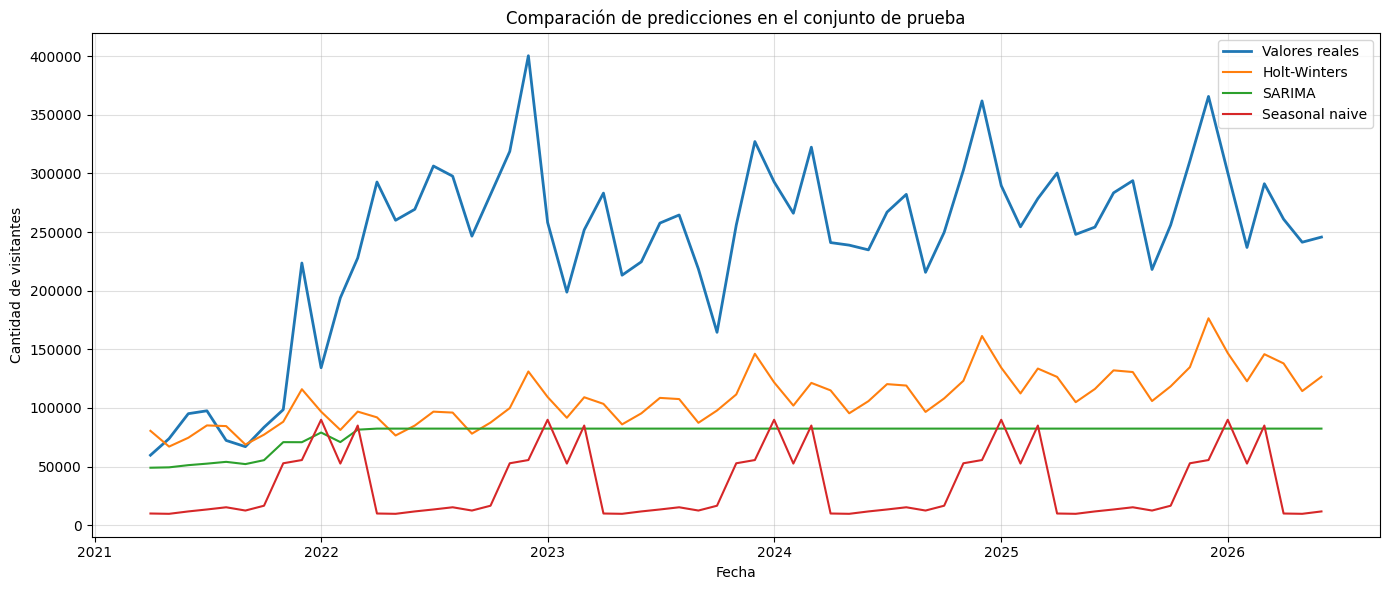

In [235]:
plt.figure(figsize=(14, 6))

plt.plot(
    serie_prueba.index, serie_prueba,
    label="Valores reales", linewidth = 2
)

plt.plot(
    prediccion_holt_winters.index,
    prediccion_holt_winters,
    label="Holt-Winters"
)

plt.plot(
    prediccion_sarima.index,
    prediccion_sarima , label = "SARIMA"
)

plt.plot(prediccion_seasonal_naive.index,
    prediccion_seasonal_naive,
    label="Seasonal naive"
)

plt.title("Comparación de predicciones en el conjunto de prueba")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de visitantes")
plt.legend()
plt.grid(alpha= 0.4 )
plt.tight_layout()
plt.show()